In [3]:
import time
import h5py
import shutil
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from chemrixs.average import Average
from chemrixs.smalldata import SmallData
from chemrixs.process import Reduced
from chemrixs.utils import *
from pathlib import Path
%matplotlib widget 

In [ ]:
os.makedirs('proc', exist_ok=True)
os.makedirs('avg', exist_ok=True)
os.makedirs('figs', exist_ok=True)

138
setting up properties
dataset prop <functools.cached_property object at 0x7fd68a6c49d0>
dataset prop <functools.cached_property object at 0x7fd68a68b850>
dataset prop <functools.cached_property object at 0x7fd68a6a5cd0>
dataset prop <functools.cached_property object at 0x7fd68bf2ec50>
dataset prop <functools.cached_property object at 0x7fd68bf2add0>
dataset prop <functools.cached_property object at 0x7fd68bf4b5d0>
dataset prop <functools.cached_property object at 0x7fd68c11ab10>
dataset prop <functools.cached_property object at 0x7fd68bf8e150>
86
setting up properties
dataset prop <functools.cached_property object at 0x7fd68a6487d0>
dataset prop <functools.cached_property object at 0x7fd68bf4fc90>
dataset prop <functools.cached_property object at 0x7fd68bf48d10>
dataset prop <functools.cached_property object at 0x7fd68a68ae90>
dataset prop <functools.cached_property object at 0x7fd68bf28090>
dataset prop <functools.cached_property object at 0x7fd7d02195d0>
scanvariable is unkown, b

/sdf/data/lcls/ds/rix/rix101231825/results/Zhaoyuan/DataAcceleratorChemRIXS/src/chemrixs/utils.py:455: RuntimeWarning: Mean of empty slice
  data_trans[ii,i] = np.nanmean(data[ii, mask])
/sdf/data/lcls/ds/rix/rix101231825/results/Zhaoyuan/DataAcceleratorChemRIXS/src/chemrixs/utils.py:456: RuntimeWarning: invalid value encountered in scalar divide
  std_trans[ii,i] = np.sqrt(np.sum(std[ii, mask]**2)) / N


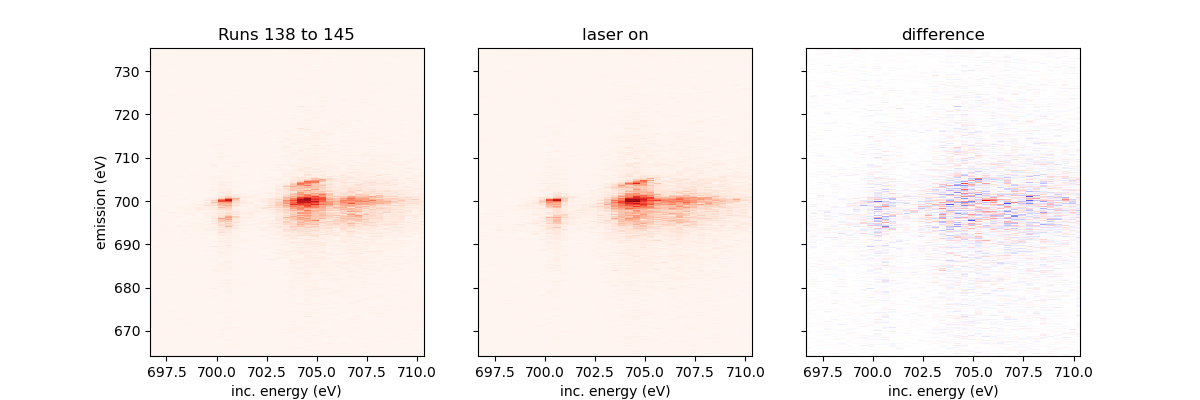

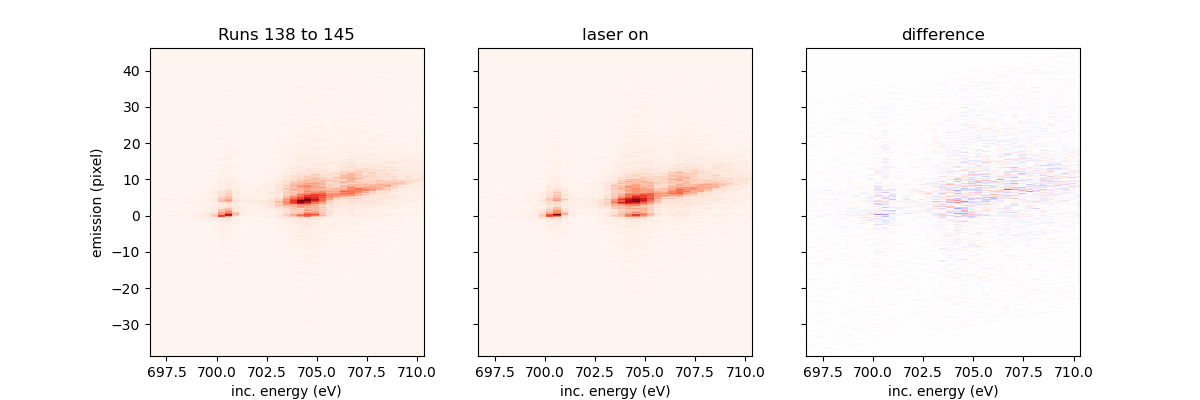

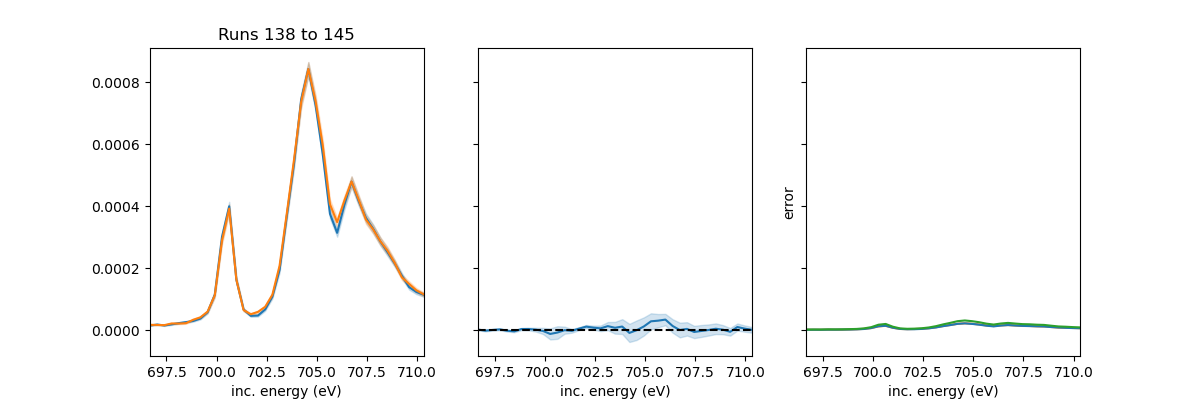

In [9]:
base_folder =  '/sdf/data/lcls/ds/rix/'
proc_folder = './proc/'


bgrun = 86 #shift2
# bgrun = 86 #shift3
# bgrun = 191 #shift4

# runs = [45,46]
# runs=[112,114,115,116,117,118,119,120,121,122,123,127,129,]
runs = [138,139,140,141,145]
# runs = [112,114,115,116,117,118,119,120,121,122,123,127,129,138,139,140,141,145]

# runs = [178,179,180,181,182,183,184,185,186,188]
# runs = [226]
exp = 'rix101231825'


fyaml = '../roi_input.yml'

bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
bgyaml = '../BGroi_input.yml'

avg = Average(runs, proc_path = 'proc/Run', avg = 'mean', output_path = f'avg/{runs[0]}_to_{runs[-1]}.h5',
             raw_path = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run' , bgpath = bgname, fyaml=fyaml, bgyaml=bgyaml, 
             save= True,norm = True)

avg.plot_svls2D(figsize=(12,4),savefig=True)
avg.plot_svls2D_ET(figsize=(12,4),savefig=False)
avg.plot_svls1D(figsize=(12,4))

In [24]:
base_folder = '/sdf/data/lcls/ds/rix/'
exp = 'rix101231825'
bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run0086.h5'
fyaml = '../roi_input.yml'
bgyaml = '../BGroi_input.yml'
RUN = 140
variant_tags = ['th60_tha455','th60_tha440','th70_tha455','th70_tha440',
                'th80_tha455','th80_tha440','th100_tha455','th100_tha440']
# variant_tags = ['th60_tha455','th60_tha440','th70_tha455','th70_tha440', 'th80_tha455']

os.makedirs('proc', exist_ok=True)
os.makedirs('avg', exist_ok=True)

avg_results = {}
for tag in variant_tags:
    print(f'\n===== {tag} =====')
    variant_h5  = f'{base_folder}/{exp}/hdf5/smalldata/run{RUN}_{tag}/{exp}_Run{RUN:04d}.h5'
    variant_dir = f'proc_variants/{tag}'
    os.makedirs(variant_dir, exist_ok=True)
    proc_file   = f'{variant_dir}/Run{RUN:04d}.h5'

    # reduce if not already done
    if not os.path.isfile(proc_file):
        Reduced(variant_h5, bgname, fyaml, bgyaml,
                save=True, scantype='mono_fly', norm=True)
        shutil.move(f'./proc/Run{RUN:04d}.h5', proc_file)
        print(f'  saved -> {proc_file}')

    # now Average can find it: proc_path + '0140.h5' = variant_dir/Run0140.h5
    avg = Average([RUN], proc_path=f'{variant_dir}/Run', avg='mean',
                  output_path=f'avg/{RUN}_{tag}.h5',
                  raw_path=f'{base_folder}/{exp}/hdf5/smalldata/run{RUN}_{tag}/{exp}_Run',
                  bgpath=bgname, fyaml=fyaml, bgyaml=bgyaml,
                  save=True, norm=True, scantype='mono_fly')
    avg_results[tag] = avg


===== th60_tha455 =====
proc_variants/th60_tha455/Run
[159. 207. 204. 206. 218. 207. 197. 207. 208. 198. 200. 198. 204. 203.
 203. 202. 202. 198. 198. 199. 201. 200. 211. 196. 201. 191. 201. 195.
 189. 205. 199. 196. 192. 197. 190. 196. 196. 192. 204.]

===== th60_tha440 =====
proc_variants/th60_tha440/Run
[158. 207. 204. 206. 218. 207. 197. 207. 208. 198. 200. 198. 204. 203.
 203. 202. 202. 198. 198. 199. 201. 200. 211. 196. 201. 191. 201. 195.
 189. 205. 199. 196. 192. 197. 190. 196. 196. 192. 204.]

===== th70_tha455 =====
proc_variants/th70_tha455/Run
[158. 207. 204. 206. 218. 207. 197. 207. 208. 198. 200. 198. 204. 203.
 203. 202. 202. 198. 198. 199. 201. 200. 211. 196. 201. 191. 201. 195.
 189. 205. 199. 196. 192. 197. 190. 196. 196. 192. 204.]

===== th70_tha440 =====
proc_variants/th70_tha440/Run
[157. 207. 204. 206. 218. 207. 197. 207. 208. 198. 200. 198. 204. 203.
 203. 202. 202. 198. 198. 199. 201. 200. 211. 196. 201. 191. 201. 195.
 189. 205. 199. 196. 192. 197. 190. 196. 

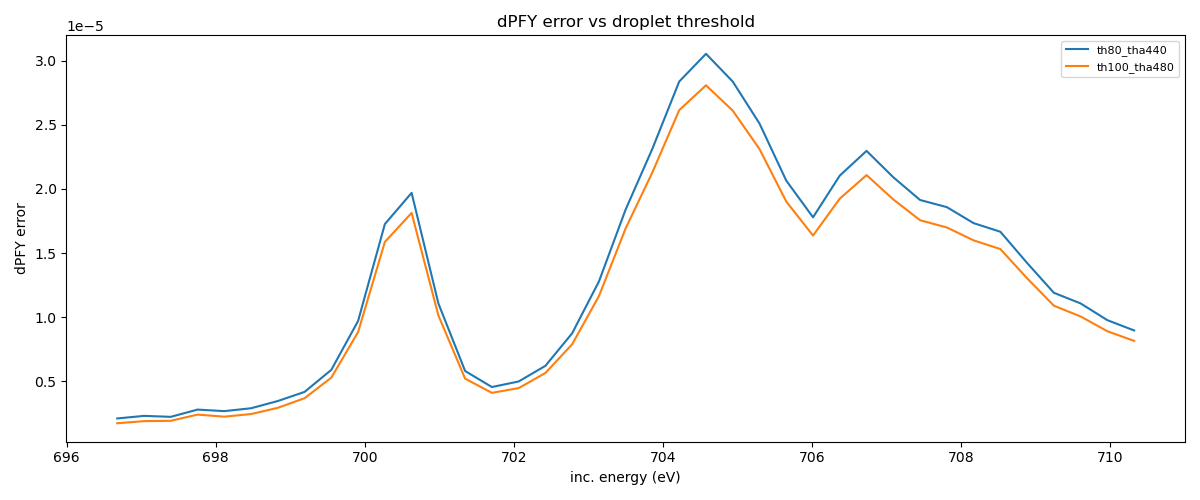

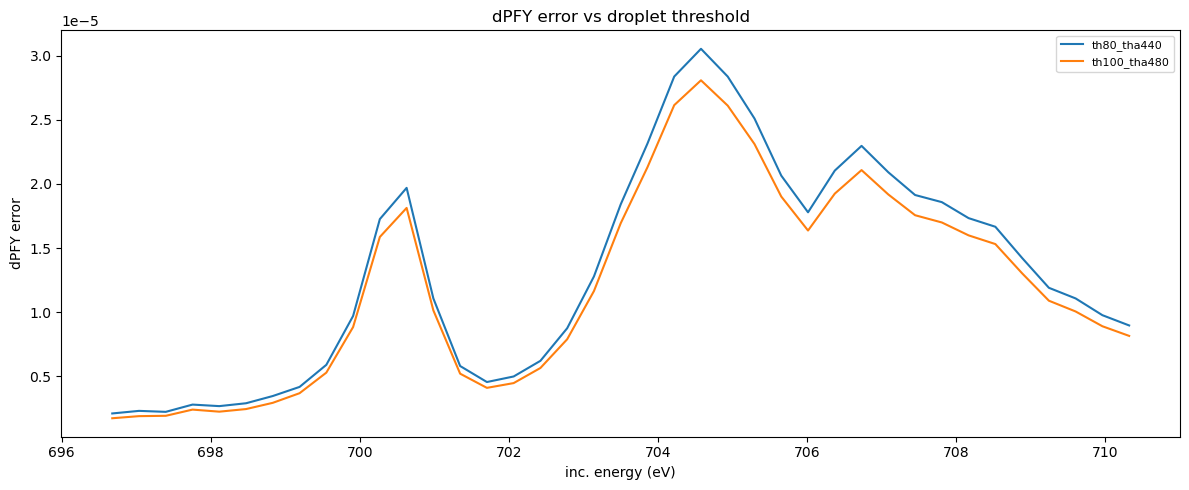

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def overlay_dPFYerr(avg_results, figsize=(12, 5)):
    """Overlay the dPFY error trace (sqrt(on_std^2 + off_std^2)) for each variant."""
    fig, ax = plt.subplots(figsize=figsize)

    for tag, avg in avg_results.items():
        a = avg.average
        # make sure PFYs exist (get_PFYs populates PFY_*_mean / PFY_*_std)
        if 'PFY_on_std' not in a:
            avg.get_PFYs()
            a = avg.average

        scanvar = a['scanvar_off']
        dPFYerr = np.sqrt(a['PFY_on_std']**2 + a['PFY_off_std']**2)
        ax.plot(scanvar, dPFYerr, label=tag)

    ax.set_xlabel('inc. energy (eV)')
    ax.set_ylabel('dPFY error')
    ax.set_title('dPFY error vs droplet threshold')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    return fig

overlay_dPFYerr(avg_results)

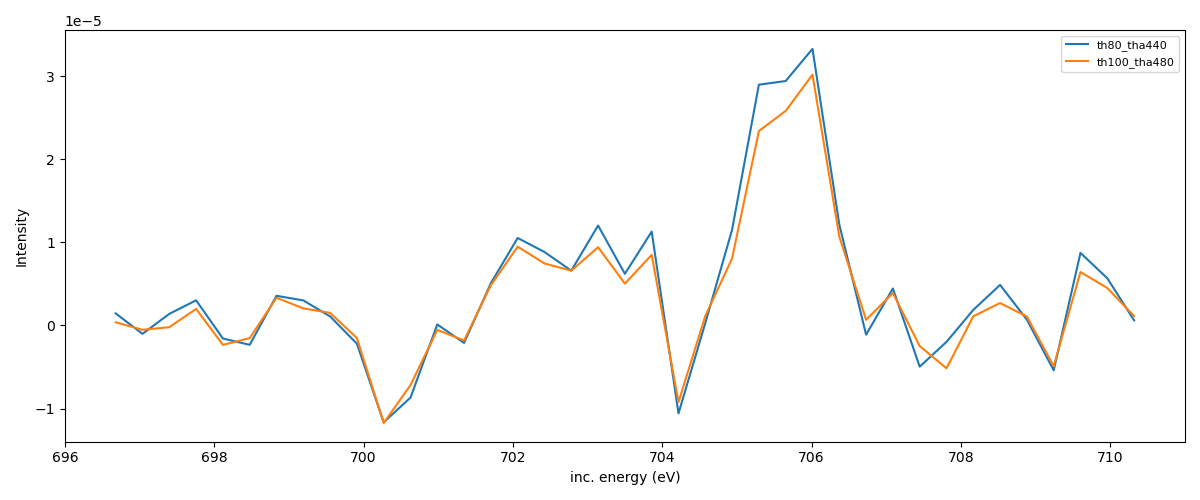

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
for tag, avg in avg_results.items():
        a = avg.average
    # make sure PFYs exist (get_PFYs populates PFY_*_mean / PFY_*_std)
        if 'PFY_on_std' not in a:
            avg.get_PFYs()
            a = avg.average

        scanvar = a['scanvar_off']
        # dPFYerr = np.sqrt(a['PFY_on_std']**2 + a['PFY_off_std']**2)
        ax.plot(scanvar, a['PFY_on_mean']-a['PFY_off_mean'], label=tag)

ax.set_xlabel('inc. energy (eV)')
ax.set_ylabel('Intensity')
# ax.set_title('dPFY error vs droplet threshold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

for plotting avg of a few runs using different noise/adu threshold

In [5]:
base_folder = '/sdf/data/lcls/ds/rix/'
exp = 'rix101231825'
bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run0086.h5'
fyaml = '../roi_input.yml'
bgyaml = '../BGroi_input.yml'

runs = [138, 139, 140, 141, 145]
variant_tags = ['th80_tha440', 'th100_tha480']

os.makedirs('proc', exist_ok=True)
os.makedirs('avg', exist_ok=True)

avg_results = {}
for tag in variant_tags:
    print(f'\n===== variant {tag} =====')
    variant_dir = f'proc_variants/{tag}'
    os.makedirs(variant_dir, exist_ok=True)

    # --- reduce every run for this variant ---
    for RUN in runs:
        variant_h5 = f'{base_folder}/{exp}/hdf5/smalldata/run{RUN}_{tag}/{exp}_Run{RUN:04d}.h5'
        proc_file  = f'{variant_dir}/Run{RUN:04d}.h5'

        if not os.path.isfile(proc_file):
            if not os.path.isfile(variant_h5):
                print(f'  !! MISSING raw file, skipping: {variant_h5}')
                continue
            print(f'  reducing run {RUN} ...')
            Reduced(variant_h5, bgname, fyaml, bgyaml,
                    save=True, scantype='mono_fly', norm=True)
            # Reduced always writes ./proc/RunXXXX.h5 — move it into the variant folder
            shutil.move(f'./proc/Run{RUN:04d}.h5', proc_file)
            print(f'    saved -> {proc_file}')
        else:
            print(f'  run {RUN} already reduced -> {proc_file}')

    # --- average all runs for this variant ---
    # Average reads proc_path + f'{run:04d}.h5' for each run in `runs`,
    # so all proc files must sit in variant_dir named RunXXXX.h5  (they do)
    avg = Average(runs, proc_path=f'{variant_dir}/Run', avg='mean',
                  output_path=f'avg/{runs[0]}_to_{runs[-1]}_{tag}.h5',
                  raw_path=f'{base_folder}/{exp}/hdf5/smalldata/REPLACED_BELOW',
                  bgpath=bgname, fyaml=fyaml, bgyaml=bgyaml,
                  save=True, norm=True, scantype='mono_fly')
    avg_results[tag] = avg
    print(f'  averaged {len(runs)} runs for {tag}')


===== variant th80_tha440 =====
  reducing run 138 ...
138
setting up properties
dataset prop <functools.cached_property object at 0x7fd68c3099d0>
dataset prop <functools.cached_property object at 0x7fd68c113150>
dataset prop <functools.cached_property object at 0x7fd68c3393d0>
dataset prop <functools.cached_property object at 0x7fd68c33b0d0>
dataset prop <functools.cached_property object at 0x7fd68c31a690>
dataset prop <functools.cached_property object at 0x7fd6944f41d0>
dataset prop <functools.cached_property object at 0x7fd7e95fe450>
dataset prop <functools.cached_property object at 0x7fd69473e910>
86
setting up properties
dataset prop <functools.cached_property object at 0x7fd6950a2610>
dataset prop <functools.cached_property object at 0x7fd68c328b10>
dataset prop <functools.cached_property object at 0x7fd68c349090>
dataset prop <functools.cached_property object at 0x7fd68c326090>
dataset prop <functools.cached_property object at 0x7fd68c118450>
dataset prop <functools.cached_prop